# K03_02 – Metriken bei Regressionsmodellen – Dozentenversion

Diese Fassung enthält **Musterlösungen und kurze didaktische Hinweise**.

In diesem Notebook bewerten wir ein **Regressionsmodell**.  
Dabei betrachten wir die wichtigsten Kennzahlen:
- MAE
- MSE
- RMSE
- R²

## Lernziele
Nach diesem Notebook können Sie:
- Vorhersagefehler eines Regressionsmodells quantifizieren
- MAE, MSE, RMSE und R² unterscheiden
- ein Modell mit einem Merkmal und ein Modell mit mehreren Merkmalen vergleichen

## Der Diabetes-Datensatz

Für dieses Notebook verwenden wir den **Diabetes-Datensatz** aus `sklearn.datasets`.
Es handelt sich um einen realen medizinischen Datensatz, der häufig als Benchmark
für Regressionsmodelle eingesetzt wird.

**Aufgabenstellung:** Vorhersage des Krankheitsfortschritts (ein Jahr nach der Messung)
anhand von 10 medizinischen Messgrößen.

Da die Zielvariable **kontinuierlich** ist (keine Klassen, sondern echte Zahlenwerte),
ist dies eine typische **Regressionsaufgabe**.

## 1. Datensatz laden

Wir verwenden den `diabetes`-Datensatz aus scikit-learn.  
Das Ziel ist ein kontinuierlicher Zielwert – also ein klassisches Regressionsproblem.


In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)

# Zielwert y: Krankheitsfortschritt ein Jahr nach der Messung (kontinuierliche Zahl)
y = data.target
y[:10]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])

## Die Feature-Matrix X

Die Feature-Matrix `X` hat den Shape `(442, 10)` — das bedeutet:
- **442 Samples** (Zeilen): eine Zeile pro Patient
- **10 Features** (Spalten): medizinische Messgrößen pro Patient

| Spalten-Index | Feature-Name | Bedeutung |
|:---:|:---:|---|
| 0 | `age` | Alter |
| 1 | `sex` | Geschlecht (kodiert) |
| 2 | `bmi` | Body-Mass-Index |
| 3 | `bp` | Mittlerer Blutdruck |
| 4 | `s1` | Gesamtcholesterin |
| 5 | `s2` | LDL-Cholesterin |
| 6 | `s3` | HDL-Cholesterin |
| 7 | `s4` | Cholesterin/HDL-Verhältnis |
| 8 | `s5` | log(Serumtriglyceride) |
| 9 | `s6` | Blutzucker (Nüchternwert) |

> **Hinweis:** Alle Features sind bereits **standardisiert** geliefert
> (Mittelwert ≈ 0, Standardabweichung ≈ 1). Ein zusätzlicher `StandardScaler`-Schritt
> ist daher für diesen Datensatz nicht zwingend erforderlich.

### Der Ziel-Vektor y

Der Ziel-Vektor `y` enthält für jeden Patienten einen **quantitativen Messwert**,
der den Krankheitsfortschritt nach einem Jahr beschreibt.

- Shape: `(442,)` — ein Wert pro Patient
- Wertebereich: ca. 25 bis 346
- Mittelwert: ca. 152

Da `y` keine Klassen, sondern **kontinuierliche Zahlenwerte** enthält,
sprechen wir von einer **Regressionsaufgabe** — und verwenden entsprechend
Regressionsmetriken wie MAE, MSE, RMSE und R².

## Warum Regressionsmetriken?

Ein Klassifikationsmodell würde hier keinen Sinn ergeben, weil `y` keine diskreten
Klassen enthält. Stattdessen messen wir, **wie weit die Vorhersage vom wahren Wert
abweicht** — das ist die Kernfrage der Regressionsmetriken:

- **MAE**: mittlere absolute Abweichung (robust, leicht interpretierbar)
- **MSE**: mittlere quadratische Abweichung (bestraft große Fehler stärker)
- **RMSE**: Wurzel aus MSE (gleiche Einheit wie `y`)
- **R²**: Anteil der erklärten Varianz (1.0 = perfekt, 0.0 = kein Erklärungswert)

In [2]:
print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
X.head()

# Warum sind alle Werte so klein (z.B. 0.038)?
# Die Daten sind bereits standardisiert — scikit-learn liefert den Datensatz
# fertig skaliert. Deshalb braucht man hier keinen StandardScaler mehr
# zusätzlich anzuwenden.

Shape von X: (442, 10)
Shape von y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Ein einfaches Modell mit nur einem Merkmal

Wir beginnen bewusst einfach und verwenden nur das Merkmal `bmi`.


In [3]:
X_one = X[["bmi"]]

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_one, y, test_size=0.25, random_state=42
)

model_one = LinearRegression()
model_one.fit(X_train_1, y_train_1)

y_pred_1 = model_one.predict(X_test_1)


In [4]:
mae_1 = mean_absolute_error(y_test_1, y_pred_1)
mse_1 = mean_squared_error(y_test_1, y_pred_1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test_1, y_pred_1)

print("Modell mit 1 Merkmal (bmi)")
print(f"MAE :  {mae_1:.3f}")
print(f"MSE :  {mse_1:.3f}")
print(f"RMSE:  {rmse_1:.3f}")
print(f"R²  :  {r2_1:.3f}")


Modell mit 1 Merkmal (bmi)
MAE :  49.805
MSE :  3775.617
RMSE:  61.446
R²  :  0.317


## Mini-Übung 1
Wie würden Sie die Kennzahlen interpretieren?
- Welche Metrik ist in der Originaleinheit des Zielwerts?
- Welche Metrik bestraft große Fehler besonders stark?


### Musterlösung / Dozentenhinweis
- **MAE** und **RMSE** liegen in der **Originaleinheit** der Zielvariable.
- **MSE** und damit indirekt auch **RMSE** bestrafen große Fehler stärker; besonders klar sieht man das beim **MSE**, weil die Fehler quadriert werden.

Didaktisch hilfreich: erst die Einheit besprechen, dann die Frage, wie stark Ausreißer bestraft werden.

## 3. Modell mit allen Merkmalen


In [5]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

y_pred_all = model_all.predict(X_test_all)


In [6]:
mae_all = mean_absolute_error(y_test_all, y_pred_all)
mse_all = mean_squared_error(y_test_all, y_pred_all)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(y_test_all, y_pred_all)

print("Modell mit allen Merkmalen")
print(f"MAE :  {mae_all:.3f}")
print(f"MSE :  {mse_all:.3f}")
print(f"RMSE:  {rmse_all:.3f}")
print(f"R²  :  {r2_all:.3f}")


Modell mit allen Merkmalen
MAE :  41.549
MSE :  2848.311
RMSE:  53.370
R²  :  0.485


## 4. Direkter Vergleich


In [7]:
vergleich = pd.DataFrame({
    "Modell": ["Nur bmi", "Alle Merkmale"],
    "MAE": [mae_1, mae_all],
    "MSE": [mse_1, mse_all],
    "RMSE": [rmse_1, rmse_all],
    "R2": [r2_1, r2_all]
})

vergleich.round(3)


,Modell,MAE,MSE,RMSE,R2
0,Nur bmi,49.805,3775.617,61.446,0.317
1,Alle Merkmale,41.549,2848.311,53.370,0.485


## Mini-Übung 2
1. Welches Modell ist besser?
2. Woran erkennen Sie das?
3. Ist ein höheres R² immer automatisch ein Beweis für ein gutes Modell?


### Musterlösung / Dozentenhinweis
1. Das bessere Modell hat typischerweise **kleinere Fehlermaße** (MAE, RMSE) und ein **höheres R²**.
2. Man erkennt das also an einem **günstigeren Gesamtbild der Kennzahlen**.
3. **Nein**, ein höheres R² allein beweist noch nicht automatisch ein gutes Modell. Ein Modell kann trotzdem fachlich unpassend sein oder auf neuen Daten schlechter generalisieren.

Merksatz: Metriken helfen bei der Bewertung, ersetzen aber nicht die fachliche Interpretation.

## 5. Visualisierung der Vorhersagen


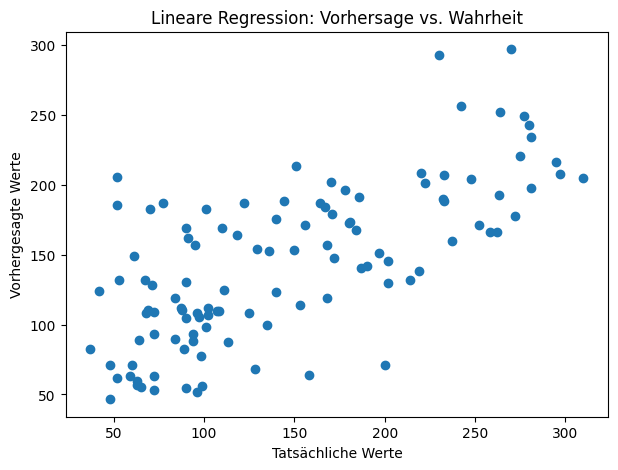

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test_all, y_pred_all)
plt.xlabel("Tatsächliche Werte")
plt.ylabel("Vorhergesagte Werte")
plt.title("Lineare Regression: Vorhersage vs. Wahrheit")
plt.show()


### Beobachtung
Je näher die Punkte an einer gedachten Diagonalen liegen, desto besser sind Vorhersage und Wahrheit in Übereinstimmung.


## 6. Zusammenfassung

- **MAE** misst den durchschnittlichen absoluten Fehler
- **MSE** bestraft große Fehler stärker
- **RMSE** ist wieder in der Originaleinheit interpretierbar
- **R²** misst, wie viel Varianz erklärt wird

Keine einzelne Kennzahl erzählt immer die ganze Geschichte.
